# Week 1: Scoliosis Cobb-Angle Data Cleaning and EDA

**Project:** Data-driven evaluation of automated Cobb-angle estimation

This notebook documents the first stage of the project: understanding the released CSV, parsing its list-valued measurements, constructing analysis-ready tables, and producing preliminary descriptive results.

The results shown here are **descriptive only**. Curves have not yet been matched anatomically across observers, so the notebook does not claim that one method is more accurate or reliable.


## 1. Measurement pathways

The dataset contains three conceptually different pathways:

1. **Traditional manual Cobb:** a human chooses end vertebrae and draws the Cobb lines.
2. **Human centroids + spline:** a human marks vertebral centers, then an algorithm fits a spline and calculates curve angles.
3. **Neural-network centroids + spline:** the neural network predicts vertebral centers, then the same type of spline calculation produces the angles.

The duplicated neural-network `val_` columns are not treated as an additional independent method.


## 2. Setup and load the raw CSV


In [1]:
from pathlib import Path
import ast
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# These options support Jupyter from the repository root, Jupyter from
# the notebooks folder, and a direct upload in Google Colab.
candidates = [
    Path("data/raw/scoliosis_measurements.csv"),
    Path("../data/raw/scoliosis_measurements.csv"),
    Path("/content/scoliosis_measurements.csv"),
]
DATA_PATH = next((path for path in candidates if path.exists()), candidates[0])

raw = pd.read_csv(DATA_PATH)
raw = raw.rename(columns={raw.columns[0]: "image_id"})
raw["image_id"] = raw["image_id"].astype("string")
print(raw.shape)
raw.head(3)

(543, 31)


The table contains 543 cases, one identifier column, and 30 measurement columns. The first column is renamed `image_id`; the original measurements are not changed.


## 3. Parse and validate the list-valued columns


In [2]:
def parse_list(value):
    if pd.isna(value):
        return None
    parsed = ast.literal_eval(value)
    if not isinstance(parsed, list):
        raise ValueError(f"Expected list, received: {value!r}")
    return parsed

# Parse all relevant cells and check whether angle lists have matching
# vertebral-pair lists.
human_observers = ["carl", "peter", "marlene", "wadim"]
all_sources = human_observers + ["neuralnet"]
length_mismatches = []
for source in all_sources:
    for prefix in ["", "val_"]:
        angle_col = f"{prefix}COBB_angles_{source}"
        pair_col = f"{prefix}COBB_vertebrae_{source}"
        for image_id, angle_cell, pair_cell in raw[["image_id", angle_col, pair_col]].itertuples(index=False):
            angles, pairs = parse_list(angle_cell), parse_list(pair_cell)
            if angles is None and pairs is None:
                continue
            if angles is None or pairs is None or len(angles) != len(pairs):
                length_mismatches.append((image_id, angle_col, pair_col))

print("Eight-character alphanumeric IDs:", raw.image_id.str.fullmatch(r"[A-Z0-9]{8}").all())
print("Duplicate IDs:", raw.image_id.duplicated().sum())
print("List parse errors:", 0)
print("Angle/vertebral-pair availability or length mismatches:", len(length_mismatches))

Eight-character alphanumeric IDs: True
Duplicate IDs: 0
List parse errors: 0
Angle/vertebral-pair availability or length mismatches: 3


A missing cell (`NaN`) and a valid empty list (`[]`) are retained as different states. An empty list means no qualifying curve was recorded; it is not automatically treated as missing.

The three mismatches are Carl manual records with angle lists but no corresponding manual vertebral-endpoint list (`T2YJ5EV4`, `D1NZZ7ER`, and `J0B27BQ8`). Their six angles remain in the case-level data but cannot enter endpoint-based curve matching.


## 4. Case-level quality-control results


In [3]:
case_level_qc = pd.DataFrame({"image_id": raw.image_id})
for source in all_sources:
    spline = raw[f"COBB_angles_{source}"].map(parse_list)
    manual = raw[f"val_COBB_angles_{source}"].map(parse_list)
    case_level_qc[f"has_spline_{source}"] = spline.notna()
    case_level_qc[f"n_spline_curves_{source}"] = spline.map(lambda x: np.nan if x is None else len(x))
    case_level_qc[f"has_manual_{source}"] = manual.notna()
    case_level_qc[f"n_manual_curves_{source}"] = manual.map(lambda x: np.nan if x is None else len(x))

complete_raw = raw.drop(columns="image_id").notna().all(axis=1)
all_human_both = case_level_qc[
    [f"has_spline_{x}" for x in human_observers] + [f"has_manual_{x}" for x in human_observers]
].all(axis=1)

print(f"Rows: {len(raw)}")
print(f"Measurement columns: {raw.shape[1] - 1}")
print(f"Unique image IDs: {raw.image_id.nunique()}")
print(f"Rows with any missing value: {(~complete_raw).sum()}")
print(f"Fully complete rows: {complete_raw.sum()}")
print(f"Missing-cell percentage: {raw.drop(columns='image_id').isna().to_numpy().mean() * 100:.2f}%")

Rows: 543
Measurement columns: 30
Unique image IDs: 543
Rows with any missing value: 48
Fully complete rows: 495
Missing-cell percentage: 1.86%


In [4]:
# Measurement availability by observer/source
for source in all_sources:
    available = int(case_level_qc[f"has_spline_{source}"].sum())
    label = "Neural network" if source == "neuralnet" else source.title()
    print(f"{label:16s} {available:3d} available / {len(raw)-available:2d} missing")

Carl             541 available /  2 missing
Peter            541 available /  2 missing
Marlene          521 available / 22 missing
Wadim            535 available /  8 missing
Neural network   527 available / 16 missing


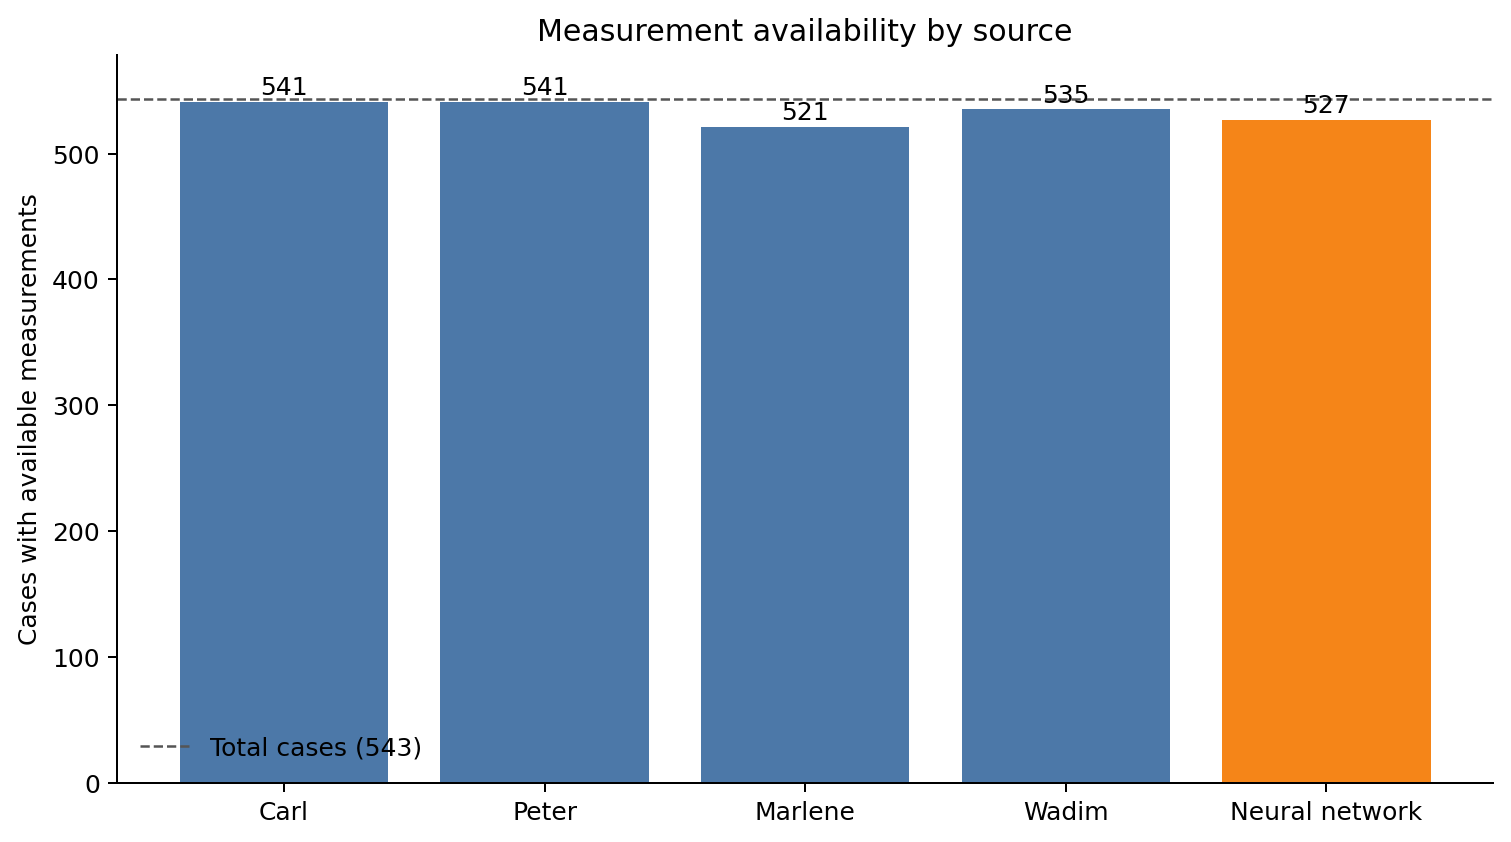

In [5]:
# Recreate with:
# available = case_level_qc[[f"has_spline_{x}" for x in sources]].sum()
# Then plot the available counts against the total of 543 cases.
from IPython.display import Image, display
figure_path = next(path for path in [Path("outputs/figures/measurement_availability.png"), Path("../outputs/figures/measurement_availability.png")] if path.exists())
display(Image(filename=str(figure_path)))

## 5. Construct the curve-level tidy table


In [6]:
display_names = {x: x.title() for x in human_observers} | {"neuralnet": "Neural network"}
curve_rows = []

def add_curves(source, method, angle_col, pair_col):
    for _, row in raw.iterrows():
        angles, pairs = parse_list(row[angle_col]), parse_list(row[pair_col])
        if angles is None or pairs is None:
            continue
        for order, (angle, pair) in enumerate(zip(angles, pairs), start=1):
            curve_rows.append({
                "image_id": row.image_id,
                "observer": display_names[source],
                "source_type": "Neural network" if source == "neuralnet" else "Human",
                "method": method,
                "curve_order_cranial_to_caudal": order,
                "angle_deg": float(angle),
                "upper_endpoint_index": int(pair[0]),
                "lower_endpoint_index": int(pair[1]),
                "visible_upper_index": row[f"upperVertebra_{source}"],
                "visible_lower_index": row[f"lowerVertebra_{source}"],
            })

for source in human_observers:
    add_curves(source, "Spline from human centroids", f"COBB_angles_{source}", f"COBB_vertebrae_{source}")
    add_curves(source, "Traditional manual Cobb", f"val_COBB_angles_{source}", f"val_COBB_vertebrae_{source}")
add_curves("neuralnet", "Spline from neural-network centroids", "COBB_angles_neuralnet", "COBB_vertebrae_neuralnet")

curve_level = pd.DataFrame(curve_rows)
print(curve_level.shape)
curve_level.head()

(9343, 9)


The tidy table excludes the duplicated neural-network `val_` fields. It includes human manual curves, human-centroid spline curves, and neural-network-centroid spline curves.


In [7]:
curve_level.groupby("method")["angle_deg"].agg(
    curve_records="size", mean_deg="mean", median_deg="median", min_deg="min", max_deg="max"
)

Human spline             n=4,301; mean=24.81°; median=24.00°; range=10°–85°
Human manual             n=4,004; mean=23.96°; median=23.00°; range=2°–75°
Neural-network spline    n=1,038; mean=24.55°; median=24.00°; range=10°–81°


## 6. Preliminary distributions


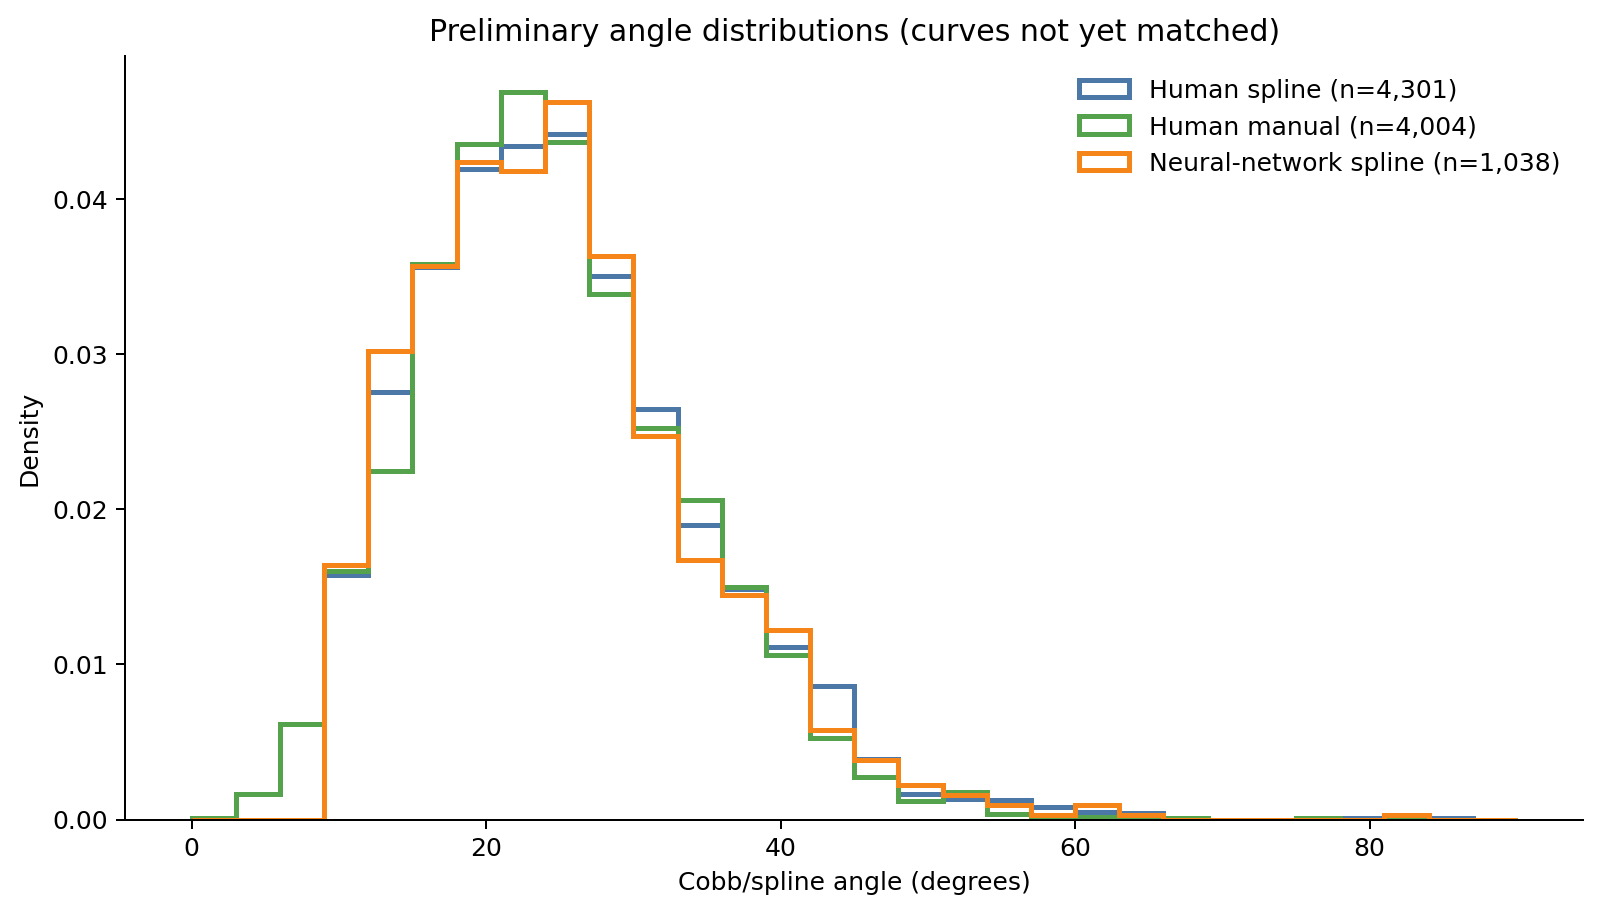

In [8]:
# The figure uses density-normalized histograms because the three pathways
# contain different numbers of curve records.
figure_path = next(path for path in [Path("outputs/figures/angle_distributions.png"), Path("../outputs/figures/angle_distributions.png")] if path.exists())
display(Image(filename=str(figure_path)))

The three distributions appear broadly similar, with medians of approximately 23°–24°. This is not an agreement analysis: the underlying curves have not yet been matched within images.


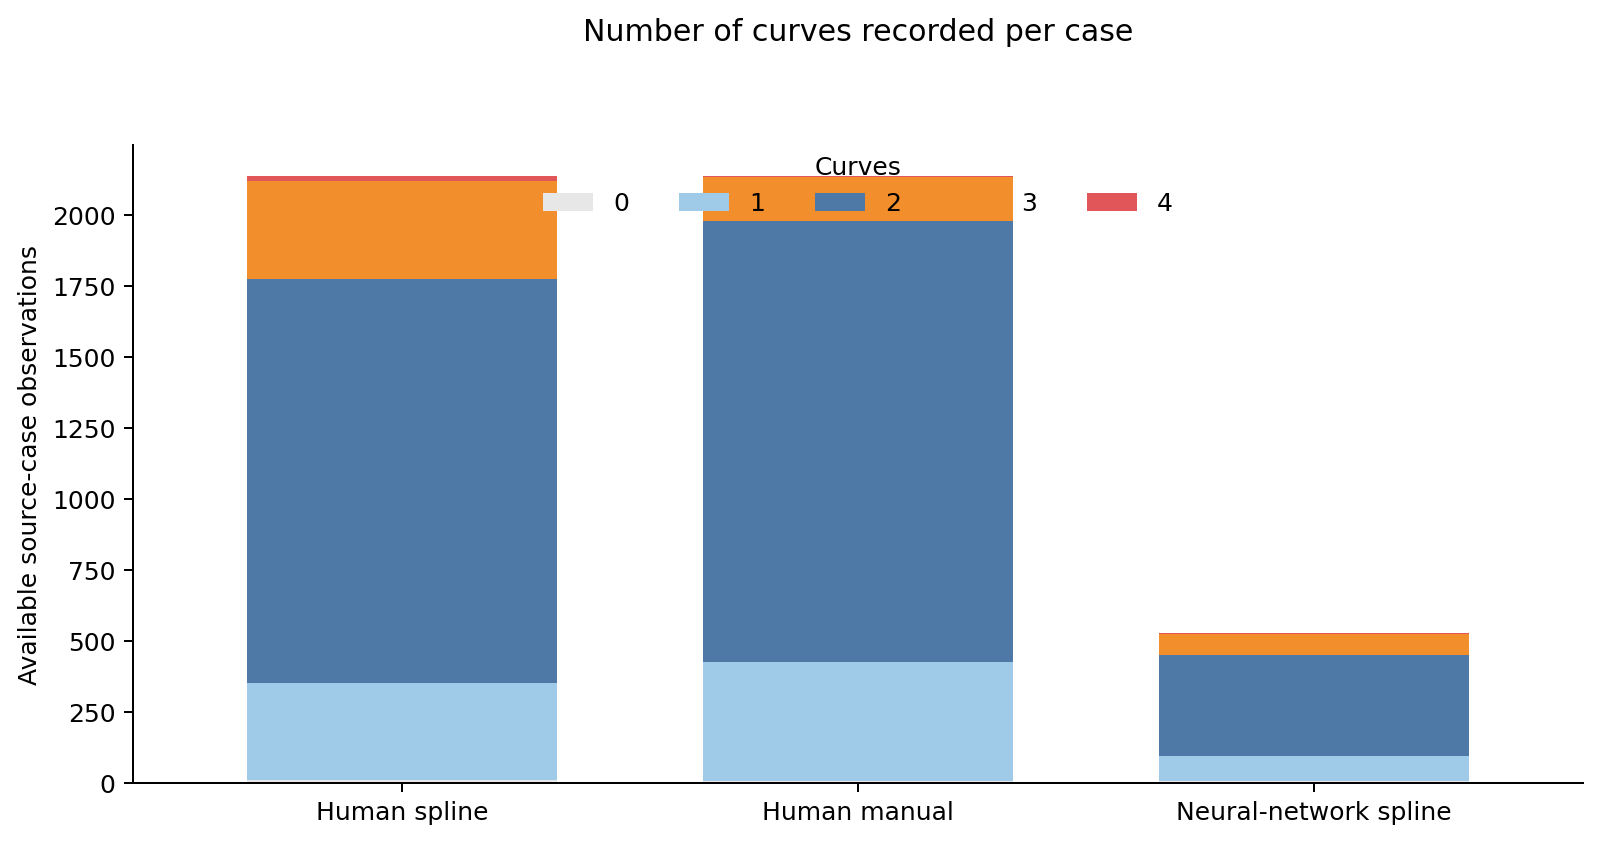

In [9]:
# Number of curves recorded per available source-case observation
figure_path = next(path for path in [Path("outputs/figures/curve_counts_per_case.png"), Path("../outputs/figures/curve_counts_per_case.png")] if path.exists())
display(Image(filename=str(figure_path)))

Most available source-case observations contain two curves, but zero through four curves occur. This confirms that list position alone is not a safe curve-matching key.


## 7. Week 1 findings

- The released CSV contains **543 unique cases** and no duplicate identifiers.
- **495 cases** are complete across all 30 measurement columns.
- **511 cases** contain both measurement methods from all four human observers.
- **527 cases** contain neural-network spline results.
- Missing cells represent **1.86%** of measurement cells.
- All non-missing list-valued cells parse successfully. **3 cases** have a manual angle list without its corresponding end-point list; these six incomplete curve records are retained at case level but excluded from the endpoint-complete tidy table.
- Different observers can identify different numbers of curves in the same image.
- Curve matching must occur before ICC, Bland–Altman, or error calculations are interpreted.

## 8. Next step

Develop a reproducible anatomical curve-matching rule based on vertebral intervals. After matching, calculate pairwise differences, end-vertebra disagreement, correlations, ICC where appropriate, and Bland–Altman limits of agreement.

## Sources

- [Research article](https://link.springer.com/article/10.1007/s00586-020-06577-3)
- [Released dataset](https://data.mendeley.com/datasets/ssfmrw2fg9/2)
